In [19]:
# Import relevant libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import zipfile
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from datetime import datetime
import requests
import time
from math import radians, sin, cos, sqrt, atan2

In [20]:
# Navigate to your project
os.chdir('/workspaces/DSE3101-Project')

# Verify you're in the right place
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder
os.chdir('data/raw')


Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', 'models', 'frontend', '.gitignore', 'backend', 'data', 'README.md', '.venv']


In [21]:
# Current working directory
current_dir = os.getcwd()
print(current_dir)

/workspaces/DSE3101-Project/data/raw


In [22]:
# Go up to repo root, then into data folder to retrive raw data from zip file
zip_path = os.path.join(current_dir, "ResaleFlatPrices.zip")
zip_path

'/workspaces/DSE3101-Project/data/raw/ResaleFlatPrices.zip'

In [23]:
# Loop through contents of zip file to retrieve all records and merge them
all_dfs = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    
    for csv_file in csv_files:
        with zip_ref.open(csv_file) as f:
            df = pd.read_csv(f)
            all_dfs.append(df)

# Combine into one DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"✓ Loaded {len(all_dfs)} CSV files")
print(f"✓ Total records: {len(combined_df):,}")

✓ Loaded 5 CSV files
✓ Total records: 970,969


In [24]:
print("=" * 80)
print("STEP 1: INITIAL DATA INSPECTION")
print("=" * 80)

print(f"\nDataset shape: {combined_df.shape}")
print(combined_df.info())
print(f"\nBasic statistics:\n{combined_df.describe()}")
print(f"\nUnique values per column:")
for col in combined_df.columns:
    print(f"  {col}: {combined_df[col].nunique()}")
print(f"\nFirst 5 rows:\n{combined_df.head()}")

STEP 1: INITIAL DATA INSPECTION

Dataset shape: (970969, 11)
<class 'pandas.DataFrame'>
RangeIndex: 970969 entries, 0 to 970968
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                970969 non-null  str    
 1   town                 970969 non-null  str    
 2   flat_type            970969 non-null  str    
 3   block                970969 non-null  str    
 4   street_name          970969 non-null  str    
 5   storey_range         970969 non-null  str    
 6   floor_area_sqm       970969 non-null  float64
 7   flat_model           970969 non-null  str    
 8   lease_commence_date  970969 non-null  int64  
 9   resale_price         970969 non-null  float64
 10  remaining_lease      261919 non-null  object 
dtypes: float64(2), int64(1), object(1), str(7)
memory usage: 81.5+ MB
None

Basic statistics:
       floor_area_sqm  lease_commence_date  resale_price
count   970969.000000   

In [25]:
# get current year 
current_year = datetime.now().year  

# Extract year from lease_commence_date and calculate
combined_df['lease_year'] = pd.to_datetime(combined_df['lease_commence_date']).dt.year
combined_df['remaining_lease'] = 99 - (current_year - combined_df['lease_year'])

# Clean up
combined_df = combined_df.drop('lease_year', axis=1)

print("✓ Added remaining_lease column")
print(f"Sample: {combined_df[['lease_commence_date', 'remaining_lease']].head()}")


✓ Added remaining_lease column
Sample:    lease_commence_date  remaining_lease
0                 1977               43
1                 1977               43
2                 1977               43
3                 1977               43
4                 1976               43


In [26]:
print("\n" + "=" * 80)
print("STEP 2: MISSING VALUE ANALYSIS")
print("=" * 80)

missing_summary = pd.DataFrame({
    'Missing_Count': combined_df.isnull().sum(),
    'Percentage': (combined_df.isnull().sum() / len(combined_df)) * 100,
    'Data_Type': combined_df.dtypes
})
print(missing_summary)

# Handle missing values
if combined_df.isnull().sum().sum() > 0:
    # For critical columns, drop rows
    critical_cols = ['resale_price', 'floor_area_sqm', 'lease_commence_date', 'town', 'flat_type']
    combined_df = combined_df.dropna(subset=critical_cols)
    print(f"\n✓ Dropped rows with missing critical values")
    print(f"New shape: {combined_df.shape}")


STEP 2: MISSING VALUE ANALYSIS
                     Missing_Count  Percentage Data_Type
month                            0         0.0       str
town                             0         0.0       str
flat_type                        0         0.0       str
block                            0         0.0       str
street_name                      0         0.0       str
storey_range                     0         0.0       str
floor_area_sqm                   0         0.0   float64
flat_model                       0         0.0       str
lease_commence_date              0         0.0     int64
resale_price                     0         0.0   float64
remaining_lease                  0         0.0     int32


In [27]:
print("\n" + "=" * 80)
print("STEP 3: DUPLICATE REMOVAL")
print("=" * 80)

initial_rows = len(combined_df)
duplicates = combined_df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

print(f"Duplicate rows found:")
print(combined_df[combined_df.duplicated(keep=False)].head())

if duplicates > 0:
    final_df = combined_df.drop_duplicates()
    print(f"✓ Removed {initial_rows - len(combined_df)} duplicate rows")
    print(f"New shape: {final_df.shape}")


STEP 3: DUPLICATE REMOVAL
Duplicate rows found: 2006
Duplicate rows found:
       month         town flat_type block    street_name storey_range  \
672  1990-01      GEYLANG    3 ROOM    47     CIRCUIT RD     01 TO 03   
673  1990-01      GEYLANG    3 ROOM    47     CIRCUIT RD     01 TO 03   
725  1990-01      HOUGANG    3 ROOM   308  HOUGANG AVE 5     10 TO 12   
726  1990-01      HOUGANG    3 ROOM   308  HOUGANG AVE 5     10 TO 12   
842  1990-01  JURONG WEST    3 ROOM   145    HU CHING RD     04 TO 06   

     floor_area_sqm      flat_model  lease_commence_date  resale_price  \
672            56.0        STANDARD                 1969       18000.0   
673            56.0        STANDARD                 1969       18000.0   
725            67.0  NEW GENERATION                 1983       47000.0   
726            67.0  NEW GENERATION                 1983       47000.0   
842            64.0        IMPROVED                 1976       23400.0   

     remaining_lease  
672              

In [28]:
# ============================================
# STEP 4: DATA TYPE CONVERSION & PARSING
# ============================================
print("\n" + "=" * 80)
print("STEP 4: DATA TYPE CONVERSION & PARSING")
print("=" * 80)

# Convert month to datetime
final_df['month'] = pd.to_datetime(final_df['month'], format='%Y-%m')
print("✓ Converted 'month' to datetime")

# Find middle of storey_range (e.g., Split "01 TO 05" → get both numbers → average → single storey_mid column)
split_storey = final_df['storey_range'].str.split(' TO ', expand=True).astype(int)
final_df['storey_mid'] = split_storey[[0,1]].mean(axis=1)

# Ensure numeric columns are numeric
numeric_cols = ['block', 'floor_area', 'lease_commence', 'resale_price']
for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

print("✓ Ensured numeric columns have correct data types")


STEP 4: DATA TYPE CONVERSION & PARSING
✓ Converted 'month' to datetime
✓ Ensured numeric columns have correct data types


In [29]:
# ============================================
# STEP 5: OUTLIER DETECTION & HANDLING
# ============================================
print("\n" + "=" * 80)
print("STEP 5: OUTLIER DETECTION & HANDLING")
print("=" * 80)

def detect_outliers_iqr(df, column, multiplier=1.5):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check key columns for outliers
outlier_cols = ['resale_price', 'floor_area_sqm']
outlier_stats = {}

for col in outlier_cols:
    if col in final_df.columns:
        outliers, lower, upper = detect_outliers_iqr(final_df, col)
        outlier_stats[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(final_df) * 100,
            'lower_bound': lower,
            'upper_bound': upper
        }
        print(f"\n{col}:")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(final_df)*100:.2f}%)")
        print(f"  Valid range: {lower:.2f} to {upper:.2f}")
        print(f"  Min: {final_df[col].min()}, Max: {final_df[col].max()}")

# For this project, keep outliers as they may represent genuine luxury/large flats
# But flag them for analysis
final_df['is_outlier_price'] = 0
outliers, lower, upper = detect_outliers_iqr(final_df, 'resale_price')
final_df.loc[outliers.index, 'is_outlier_price'] = 1
print(f"\n✓ Flagged {outliers.shape[0]} price outliers for analysis")


STEP 5: OUTLIER DETECTION & HANDLING

resale_price:
  Outliers: 24117 (2.49%)
  Valid range: -152500.00 to 787500.00
  Min: 5000.0, Max: 1658888.0

floor_area_sqm:
  Outliers: 2483 (0.26%)
  Valid range: 13.00 to 173.00
  Min: 28.0, Max: 366.7

✓ Flagged 24117 price outliers for analysis


In [30]:
print("\n" + "=" * 80)
print("STEP 6: FEATURE ENGINEERING")
print("=" * 80)

# Storey categories
final_df['storey_category'] = pd.cut(final_df['storey_mid'],
                                        bins=[0, 5, 10, 15, 50],
                                        labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

print("✓ Created floor_area_category")

# Categorize towns into regions (based on Singapore planning areas)
region_mapping = {
    'ANG MO KIO': 'North-East',
    'BEDOK': 'East',
    'BISHAN': 'Central',
    'BUKIT BATOK': 'West',
    'BUKIT MERAH': 'Central',
    'BUKIT PANJANG': 'West',
    'BUKIT TIMAH': 'Central',
    'CENTRAL AREA': 'Central',
    'CHOA CHU KANG': 'West',
    'CLEMENTI': 'West',
    'GEYLANG': 'Central',
    'HOUGANG': 'North-East',
    'JURONG EAST': 'West',
    'JURONG WEST': 'West',
    'KALLANG/WHAMPOA': 'Central',
    'MARINE PARADE': 'Central',
    'PASIR RIS': 'East',
    'PUNGGOL': 'North-East',
    'QUEENSTOWN': 'Central',
    'SEMBAWANG': 'North',
    'SENGKANG': 'North-East',
    'SERANGOON': 'North-East',
    'TAMPINES': 'East',
    'TOA PAYOH': 'Central',
    'WOODLANDS': 'North',
    'YISHUN': 'North'
}

final_df['region'] = final_df['town'].map(region_mapping)
final_df['region'] = final_df['region'].fillna('Other')
print("✓ Created region feature")

# Flag mature vs non-mature estates
mature_estates = ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH',
                  'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'KALLANG/WHAMPOA',
                  'MARINE PARADE', 'QUEENSTOWN', 'SERANGOON', 'TOA PAYOH']

final_df['is_mature_estate'] = final_df['town'].isin(mature_estates).astype(int)
print("✓ Created is_mature_estate flag")


STEP 6: FEATURE ENGINEERING
✓ Created floor_area_category
✓ Created region feature
✓ Created is_mature_estate flag


In [31]:
# ============================================
# STEP 7: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)
# ============================================
print("\n" + "=" * 80)
print("STEP 11: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)")
print("=" * 80)

# Town-level median price (useful for understanding relative value)
town_median_price = final_df.groupby('town')['resale_price'].median()
final_df['town_median_price'] = final_df['town'].map(town_median_price)
final_df['price_vs_town_median'] = final_df['resale_price'] / final_df['town_median_price']
print("✓ Created town_median_price")


STEP 11: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)
✓ Created town_median_price


In [32]:
# Remove negative or zero prices
print("\n1. Validating resale_price...")
print(f"   Min price: ${final_df['resale_price'].min():,.0f}")
print(f"   Max price: ${final_df['resale_price'].max():,.0f}")

invalid_prices = final_df[final_df['resale_price'] <= 0]
print(f"   Found {len(invalid_prices)} records with price <= 0")
final_df = final_df[final_df['resale_price'] > 0]

# Rule 2: Floor area must be positive and realistic
print("\n2. Validating floor_area...")
print(f"   Min area: {final_df['floor_area_sqm'].min()} sqm")
print(f"   Max area: {final_df['floor_area_sqm'].max()} sqm")

invalid_area = final_df[final_df['floor_area_sqm'] <= 0]
print(f"   Found {len(invalid_area)} records with area <= 0")
final_df = final_df[final_df['floor_area_sqm'] > 0]


1. Validating resale_price...
   Min price: $5,000
   Max price: $1,658,888
   Found 0 records with price <= 0

2. Validating floor_area...
   Min area: 28.0 sqm
   Max area: 366.7 sqm
   Found 0 records with area <= 0


Heatmap saved as correlation_heatmap.png


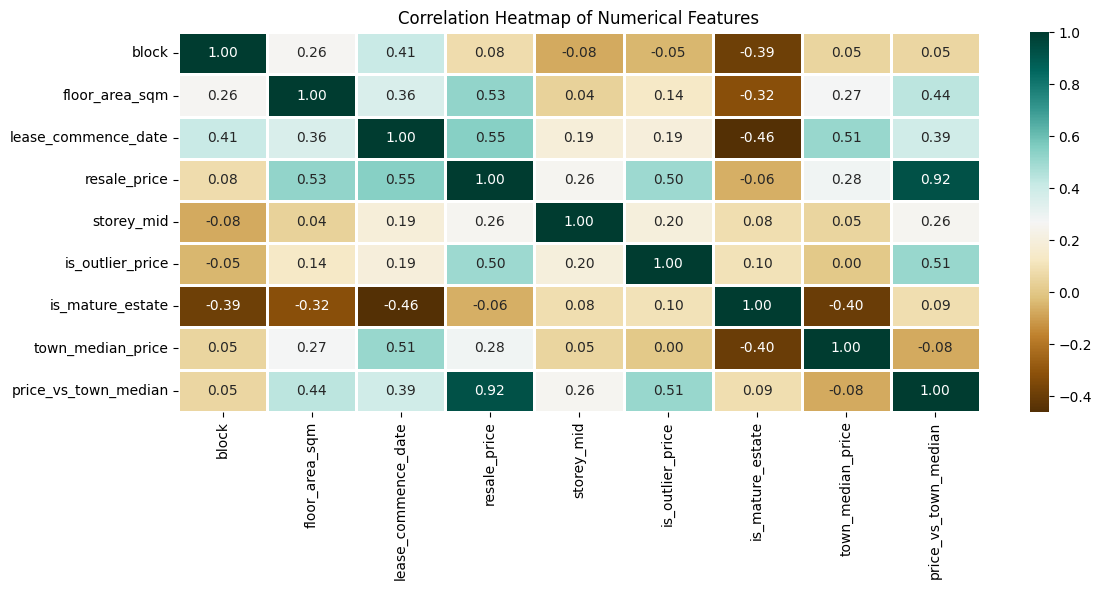

In [33]:
numerical_dataset = final_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

In [34]:
final_df['year'] = pd.to_datetime(final_df['month']).dt.year

In [35]:
# print("\n" + "=" * 80)
# print("INFLATION ADJUSTMENT TO 2008 BASE YEAR")
# print("=" * 80)

# # Singapore Consumer Price Index (CPI) data
# # Source: Department of Statistics Singapore (SingStat)
# # Base year: 2008 = 100
# singapore_cpi = {
#     1990: 65.8,
#     1991: 68.5,
#     1992: 70.9,
#     1993: 73.1,
#     1994: 75.9,
#     1995: 77.6,
#     1996: 79.1,
#     1997: 81.0,
#     1998: 80.5,
#     1999: 80.7,
#     2000: 82.1,
#     2001: 83.1,
#     2002: 82.6,
#     2003: 83.1,
#     2004: 84.8,
#     2005: 85.3,
#     2006: 86.3,
#     2007: 88.5,
#     2008: 100.0,  # Base year
#     2009: 100.6,
#     2010: 103.4,
#     2011: 108.6,
#     2012: 113.2,
#     2013: 115.9,
#     2014: 117.0,
#     2015: 116.6,
#     2016: 116.5,
#     2017: 117.2,
#     2018: 117.9,
#     2019: 118.5,
#     2020: 118.2,
#     2021: 120.8,
#     2022: 127.0,
#     2023: 132.8,
#     2024: 136.5,  # Estimated
#     2025: 140.0,  # Projected
#     2026: 143.0   # Projected
# }

# # Map CPI to each transaction year
# print("\n1. Mapping CPI values to transaction years...")
# combined_df['cpi'] = combined_df['year'].map(singapore_cpi)

# # Check for any missing CPI values
# missing_cpi = combined_df[combined_df['cpi'].isna()]
# if len(missing_cpi) > 0:
#     print(f"   ⚠️  Warning: {len(missing_cpi)} records have missing CPI values")
#     print(f"   Years with missing CPI: {missing_cpi['year'].unique()}")
    
#     # Fill missing CPI with nearest available year
#     for year in missing_cpi['year'].unique():
#         if year < min(singapore_cpi.keys()):
#             combined_df.loc[combined_df['year'] == year, 'cpi'] = singapore_cpi[min(singapore_cpi.keys())]
#             print(f"   Used {min(singapore_cpi.keys())} CPI for year {year}")
#         elif year > max(singapore_cpi.keys()):
#             combined_df.loc[combined_df['year'] == year, 'cpi'] = singapore_cpi[max(singapore_cpi.keys())]
#             print(f"   Used {max(singapore_cpi.keys())} CPI for year {year}")
# else:
#     print("   ✓ All years have CPI values")

# # Calculate inflation-adjusted (real) price
# # Formula: Real Price = Nominal Price × (Base Year CPI / Current Year CPI)
# base_year_cpi = 100.0  # 2008 CPI

# print("\n2. Calculating inflation-adjusted prices...")
# combined_df['resale_price_real_2008'] = (
#     combined_df['resale_price'] * (base_year_cpi / combined_df['cpi'])
# )

# # Round to nearest dollar
# combined_df['resale_price_real_2008'] = combined_df['resale_price_real_2008'].round(2)

# print("✓ Created resale_price_real_2008 (inflation-adjusted to 2008 dollars)")

# # Calculate the adjustment factor for reference
# combined_df['inflation_adjustment_factor'] = base_year_cpi / combined_df['cpi']

# # Show examples
# print("\n3. Sample of inflation adjustment:")
# print("="*100)
# sample_years = combined_df.groupby('year').first()[
#     ['resale_price', 'cpi', 'inflation_adjustment_factor', 'resale_price_real_2008']
# ].head(10)
# print(sample_years)

# # Calculate statistics
# print("\n4. Price comparison statistics:")
# print("="*100)
# print(f"Nominal (Original) Prices:")
# print(f"  Mean:   ${combined_df['resale_price'].mean():,.2f}")
# print(f"  Median: ${combined_df['resale_price'].median():,.2f}")
# print(f"  Min:    ${combined_df['resale_price'].min():,.2f}")
# print(f"  Max:    ${combined_df['resale_price'].max():,.2f}")

# print(f"\nReal (2008-adjusted) Prices:")
# print(f"  Mean:   ${combined_df['resale_price_real_2008'].mean():,.2f}")
# print(f"  Median: ${combined_df['resale_price_real_2008'].median():,.2f}")
# print(f"  Min:    ${combined_df['resale_price_real_2008'].min():,.2f}")
# print(f"  Max:    ${combined_df['resale_price_real_2008'].max():,.2f}")

# # Calculate real price change over time
# print("\n5. Real vs Nominal price trends by year:")
# print("="*100)
# yearly_comparison = combined_df.groupby('year').agg({
#     'resale_price': 'median',
#     'resale_price_real_2008': 'median',
#     'cpi': 'first'
# }).round(2)

# yearly_comparison['real_vs_nominal_diff'] = (
#     yearly_comparison['resale_price_real_2008'] - yearly_comparison['resale_price']
# )
# yearly_comparison['real_vs_nominal_pct'] = (
#     (yearly_comparison['resale_price_real_2008'] / yearly_comparison['resale_price'] - 1) * 100
# ).round(2)

# print(yearly_comparison.head(30))

In [36]:
import requests
def geocode_address(block, street):
    """
    Convert HDB address to latitude/longitude
    
    Example:
        geocode_address("123", "Ang Mo Kio Avenue 3")
        Returns: {'lat': 1.369115, 'lon': 103.845411}
    """
    
    # Construct full address
    full_address = f"{block} {street}"
    
    # OneMap Search API endpoint
    url = "https://www.onemap.gov.sg/api/common/elastic/search"
    
    # Parameters
    params = {
        'searchVal': full_address,
        'returnGeom': 'Y',
        'getAddrDetails': 'Y',
        'pageNum': 1
    }
    
    try:
        # Make API call
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        
        # Check if address was found
        if data.get('found', 0) > 0:
            result = data['results'][0]
            return {
                'lat': float(result['LATITUDE']),
                'lon': float(result['LONGITUDE']),
                'postal': result.get('POSTAL', ''),
                'found': True
            }
        else:
            print(f"  ⚠ Address not found: {full_address}")
            return {'found': False}
            
    except Exception as e:
        print(f"  ✗ Error geocoding {full_address}: {e}")
        return {'found': False}

# Test it
test_result = geocode_address("123", "Ang Mo Kio Avenue 3")
print("Test geocoding:", test_result)

Test geocoding: {'lat': 1.37048118793194, 'lon': 103.844805800791, 'postal': '560123', 'found': True}


In [37]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate straight-line distance between two coordinates in meters
    
    Example:
        haversine_distance(1.369, 103.845, 1.283, 103.851)
        Returns: 9542.3 (meters)
    """
    from math import radians, sin, cos, sqrt, atan2
    
    # Earth's radius in meters
    R = 6371000
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    distance = R * c
    return distance

# Test it
cbd_lat, cbd_lon = 1.283160, 103.851430  # Raffles Place
test_lat, test_lon = 1.369115, 103.845411  # AMK
distance = haversine_distance(test_lat, test_lon, cbd_lat, cbd_lon)
print(f"Distance to CBD: {distance:.0f} meters ({distance/1000:.2f} km)")

Distance to CBD: 9581 meters (9.58 km)


In [38]:
def find_nearby_amenities(lat, lon, amenity_type, radius_meters=1000):
    """
    Find amenities within a certain radius
    
    Available amenity types:
    - 'kindergartens'
    - 'schools' 
    - 'hawkercentres'
    - 'childcare'
    - 'nationalparks'
    - 'libraries'
    - 'communitycentres'
    - 'eldercare'
    
    Example:
        find_nearby_amenities(1.369, 103.845, 'hawkercentres', 500)
        Returns: {'count': 2, 'nearest_distance': 234.5, 'names': [...]}
    """
    
    # OneMap Theme API endpoint
    url = "https://www.onemap.gov.sg/api/public/themesvc/retrieveTheme"
    
    params = {
        'queryName': amenity_type,
        'lat': lat,
        'lng': lon
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        
        # Get all results
        all_results = data.get('SrchResults', [])
        
        # Filter by radius
        nearby = []
        for item in all_results:
            try:
                # Parse coordinates from "LAT,LON" format
                coords = item['LatLng'].split(',')
                item_lat = float(coords[0])
                item_lon = float(coords[1])
                
                # Calculate distance
                dist = haversine_distance(lat, lon, item_lat, item_lon)
                
                # Check if within radius
                if dist <= radius_meters:
                    nearby.append({
                        'name': item.get('NAME', 'Unknown'),
                        'distance': dist
                    })
            except:
                continue
        
        # Sort by distance
        nearby.sort(key=lambda x: x['distance'])
        
        return {
            'count': len(nearby),
            'nearest_distance': nearby[0]['distance'] if nearby else None,
            'names': [x['name'] for x in nearby[:5]]  # Top 5 nearest
        }
        
    except Exception as e:
        print(f"  ✗ Error finding {amenity_type}: {e}")
        return {'count': 0, 'nearest_distance': None, 'names': []}

# Test it
test_result = find_nearby_amenities(1.369115, 103.845411, 'hawkercentres', 1000)
print("Nearby hawker centres:", test_result)

Nearby hawker centres: {'count': 0, 'nearest_distance': None, 'names': []}


In [39]:
import time
def extract_all_features(block, street, save_progress=True):
    """
    Extract ALL location features for one HDB address
    This is the CORE function that pulls everything from OneMap
    
    Returns a dictionary with all features
    """
    
    print(f"\n{'='*60}")
    print(f"Processing: {block} {street}")
    print(f"{'='*60}")
    
    # Initialize result dictionary
    features = {
        'block': block,
        'street': street,
        'api_success': False
    }
    
    # === STEP 1: GEOCODE ADDRESS ===
    print("Step 1: Geocoding address...")
    coords = geocode_address(block, street)
    
    if not coords['found']:
        print("  ✗ Geocoding failed. Skipping this address.")
        return features
    
    lat = coords['lat']
    lon = coords['lon']
    features['latitude'] = lat
    features['longitude'] = lon
    features['postal'] = coords['postal']
    features['api_success'] = True
    
    print(f"  ✓ Coordinates: ({lat:.6f}, {lon:.6f})")
    time.sleep(0.3)  # Be respectful to API
    
    
    # === STEP 3: MRT STATIONS ===
    print("Step 3: Finding MRT stations...")
    
    # Within 500m
    mrt_500m = find_nearby_amenities(lat, lon, 'mrt', 500)
    features['num_mrt_500m'] = mrt_500m['count']
    features['nearest_mrt_dist_m'] = mrt_500m['nearest_distance']
    
    # Within 1km
    mrt_1km = find_nearby_amenities(lat, lon, 'mrt', 1000)
    features['num_mrt_1km'] = mrt_1km['count']
    
    print(f"  ✓ MRT within 500m: {mrt_500m['count']}")
    print(f"  ✓ Nearest MRT: {mrt_500m['nearest_distance']:.0f}m" if mrt_500m['nearest_distance'] else "  ✓ No MRT nearby")
    time.sleep(0.3)
    
    
    # === STEP 4: SCHOOLS ===
    print("Step 4: Finding schools...")
    
    schools_1km = find_nearby_amenities(lat, lon, 'schools', 1000)
    features['num_schools_1km'] = schools_1km['count']
    features['nearest_school_dist_m'] = schools_1km['nearest_distance']
    
    schools_2km = find_nearby_amenities(lat, lon, 'schools', 2000)
    features['num_schools_2km'] = schools_2km['count']
    
    print(f"  ✓ Schools within 1km: {schools_1km['count']}")
    time.sleep(0.3)
    
    
    # === STEP 5: HAWKER CENTRES ===
    print("Step 5: Finding hawker centres...")
    
    hawkers_500m = find_nearby_amenities(lat, lon, 'hawkercentres', 500)
    features['num_hawkers_500m'] = hawkers_500m['count']
    features['nearest_hawker_dist_m'] = hawkers_500m['nearest_distance']
    
    hawkers_1km = find_nearby_amenities(lat, lon, 'hawkercentres', 1000)
    features['num_hawkers_1km'] = hawkers_1km['count']
    
    print(f"  ✓ Hawkers within 500m: {hawkers_500m['count']}")
    time.sleep(0.3)
    
    
    # === STEP 6: PARKS ===
    print("Step 6: Finding parks...")
    
    parks_1km = find_nearby_amenities(lat, lon, 'nationalparks', 1000)
    features['num_parks_1km'] = parks_1km['count']
    features['nearest_park_dist_m'] = parks_1km['nearest_distance']
    
    print(f"  ✓ Parks within 1km: {parks_1km['count']}")
    time.sleep(0.3)
    
    
    # === STEP 8: ELDERCARE ===
    print("Step 8: Finding eldercare facilities...")
    
    eldercare_1km = find_nearby_amenities(lat, lon, 'eldercare', 1000)
    features['num_eldercare_1km'] = eldercare_1km['count']
    features['nearest_eldercare_dist_m'] = eldercare_1km['nearest_distance']
    
    print(f"  ✓ Eldercare within 1km: {eldercare_1km['count']}")
    time.sleep(0.3)
    
    
    
    # === STEP 10: COMMUNITY CENTRES ===
    print("Step 10: Finding community centres...")
    
    cc_1km = find_nearby_amenities(lat, lon, 'communitycentres', 1000)
    features['num_cc_1km'] = cc_1km['count']
    features['nearest_cc_dist_m'] = cc_1km['nearest_distance']
    
    print(f"  ✓ Community centres within 1km: {cc_1km['count']}")
    time.sleep(0.5)
    
    
    print(f"\n✓ COMPLETED: {block} {street}")
    print(f"  Total features extracted: {len(features)}")
    
    return features

In [40]:
# Test on ONE address
test_features = extract_all_features("766", "BEDOK RESERVOIR VIEW")

# Display the results
print("\n" + "="*60)
print("EXTRACTED FEATURES:")
print("="*60)
for key, value in test_features.items():
    print(f"{key:30s}: {value}")


Processing: 766 BEDOK RESERVOIR VIEW
Step 1: Geocoding address...


  ✓ Coordinates: (1.335999, 103.936275)
Step 3: Finding MRT stations...
  ✓ MRT within 500m: 0
  ✓ No MRT nearby
Step 4: Finding schools...
  ✓ Schools within 1km: 0
Step 5: Finding hawker centres...
  ✓ Hawkers within 500m: 0
Step 6: Finding parks...
  ✓ Parks within 1km: 0
Step 8: Finding eldercare facilities...
  ✓ Eldercare within 1km: 0
Step 10: Finding community centres...
  ✓ Community centres within 1km: 0

✓ COMPLETED: 766 BEDOK RESERVOIR VIEW
  Total features extracted: 21

EXTRACTED FEATURES:
block                         : 766
street                        : BEDOK RESERVOIR VIEW
api_success                   : True
latitude                      : 1.33599899207348
longitude                     : 103.936274523658
postal                        : 470766
num_mrt_500m                  : 0
nearest_mrt_dist_m            : None
num_mrt_1km                   : 0
num_schools_1km               : 0
nearest_school_dist_m         : None
num_schools_2km               : 0
num_hawkers_500m  

In [41]:
final_df.head(10)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease,storey_mid,is_outlier_price,storey_category,region,is_mature_estate,town_median_price,price_vs_town_median,year
0,1990-01-01,ANG MO KIO,1 ROOM,309.0,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,43,11.0,0,Mid-High,North-East,1,230000.0,0.039130,1990
1,1990-01-01,ANG MO KIO,1 ROOM,309.0,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,43,5.0,0,Low,North-East,1,230000.0,0.026087,1990
2,1990-01-01,ANG MO KIO,1 ROOM,309.0,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,43,11.0,0,Mid-High,North-East,1,230000.0,0.034783,1990
3,1990-01-01,ANG MO KIO,1 ROOM,309.0,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,43,8.0,0,Mid-Low,North-East,1,230000.0,0.026087,1990
4,1990-01-01,ANG MO KIO,3 ROOM,216.0,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,43,5.0,0,Low,North-East,1,230000.0,0.205217,1990
5,1990-01-01,ANG MO KIO,3 ROOM,211.0,ANG MO KIO AVE 3,01 TO 03,67.0,NEW GENERATION,1977,46000.0,43,2.0,0,Low,North-East,1,230000.0,0.200000,1990
6,1990-01-01,ANG MO KIO,3 ROOM,202.0,ANG MO KIO AVE 3,07 TO 09,67.0,NEW GENERATION,1977,42000.0,43,8.0,0,Mid-Low,North-East,1,230000.0,0.182609,1990
7,1990-01-01,ANG MO KIO,3 ROOM,235.0,ANG MO KIO AVE 3,10 TO 12,67.0,NEW GENERATION,1977,38000.0,43,11.0,0,Mid-High,North-East,1,230000.0,0.165217,1990
8,1990-01-01,ANG MO KIO,3 ROOM,235.0,ANG MO KIO AVE 3,04 TO 06,67.0,NEW GENERATION,1977,40000.0,43,5.0,0,Low,North-East,1,230000.0,0.173913,1990
9,1990-01-01,ANG MO KIO,3 ROOM,232.0,ANG MO KIO AVE 3,01 TO 03,67.0,NEW GENERATION,1977,47000.0,43,2.0,0,Low,North-East,1,230000.0,0.204348,1990


In [43]:
final_df.to_pickle('../../backend/final_df.pkl', compression='gzip')